In [1]:
import pandas as pd 
import numpy as np
import librosa 
import os
from collections import Counter
from sklearn.feature_selection import SelectKBest, f_classif
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import make_column_transformer
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [2]:
dataset_path = r"D:\DSA and Coding\tpds emotion project\Radvess"

In [3]:
emotion_dict = {
    '01': 'neutral',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry'
}

The Python os.path.join() method intelligently combines one or more path components into a single, valid path string, automatically using the correct path separator (/ on Unix/Linux, \ on Windows) for the operating system where the code is running.

In [4]:
file_path = []
emotion = []

for actor in os.listdir(dataset_path):
    actor_path = os.path.join(dataset_path, actor)

    for file in os.listdir(actor_path):
        parts = file.split('-')
        emotion_code = parts[2]

        if emotion_code not in emotion_dict :
            continue

        file_path.append(os.path.join(actor_path, file))
        emotion.append(emotion_dict[emotion_code])

In [5]:
df = pd.DataFrame()

df['path'] = file_path
df['emotion'] = emotion

df.head()

,path,emotion
0,D:\DSA and Coding\tpds emotion project\Radvess...,neutral
1,D:\DSA and Coding\tpds emotion project\Radvess...,neutral
2,D:\DSA and Coding\tpds emotion project\Radvess...,neutral
3,D:\DSA and Coding\tpds emotion project\Radvess...,neutral
4,D:\DSA and Coding\tpds emotion project\Radvess...,happy


In [6]:
df.shape

(672, 2)

MFCC tells how the human ear would hear the sound.
hop = 7.2 ms 
frame rate = 

In [7]:
def extract_features(audio, sr):

    features = []

    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40, n_fft=2048)

    delta = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)

    features.extend(np.mean(mfcc, axis=1))
    features.extend(np.std(mfcc, axis=1))

    features.extend(np.mean(delta, axis=1))
    features.extend(np.mean(delta2, axis=1))

    rms = librosa.feature.rms(y=audio)
    features.extend([np.mean(rms), np.std(rms)])

    centroid = librosa.feature.spectral_centroid(y=audio, sr=sr) # Represents the "center of mass" of the spectrum, indicating where the bulk of the signal's energy is located
    bandwidth = librosa.feature.spectral_bandwidth(y=audio, sr=sr) # Measures the spread of the spectrum around the spectral centroid.
    rolloff = librosa.feature.spectral_rolloff(y=audio, sr=sr) # frequency below which a certain percentage (e.g., 85%) of the total spectral energy resides.
    contrast = librosa.feature.spectral_contrast(y=audio, sr=sr) # Highlights the difference between peaks (harmonics) and valleys (non-harmonics) in a spectrum

    features.extend([np.mean(centroid), np.std(centroid)])
    features.extend([np.mean(bandwidth), np.std(bandwidth)])
    features.extend([np.mean(rolloff), np.std(rolloff)])
    features.extend(np.mean(contrast, axis=1))

    chroma = librosa.feature.chroma_stft(y=audio, sr=sr) # n_chroma specifies how many pitch classes are used to represent the harmonic content of a frame of audio
    features.extend(np.mean(chroma, axis=1))
    features.extend(np.std(chroma, axis=1))

    zcr = librosa.feature.zero_crossing_rate(y=audio)
    features.extend([np.mean(zcr), np.std(zcr)])

    return np.array(features)

The zip() function is a built-in utility in several programming languages (most notably Python, which is the common context for this type of query) used to combine elements from multiple iterables (like lists, tuples, or strings) into a single iterator of tuples

In [8]:
X = []
y = []

for path, emo in zip(df['path'], df['emotion']):

    audio, sr = librosa.load(path, duration=5, offset=0.5)

    # print(audio.shape)
    # print(sr)

    audio = np.array(audio)

    # original audio
    X.append(extract_features(audio, sr))
    y.append(emo)

In [9]:
X = np.array(X)
Y = np.array(y)

672 files as 2688/4 

In [10]:
X.shape

(672, 201)

In [11]:
# y = pd.get_dummies(y, dtype=int)
le = LabelEncoder()
y = le.fit_transform(y)
# y = to_categorical(le.fit_transform(y))

to_categorical converts numbers such that [1, 2, 3] to [[1,0,0], [0,1,0], [0,0,1]]

In [12]:
le.classes_

array(['angry', 'happy', 'neutral', 'sad'], dtype='<U7')

In [13]:
print(Counter(y)) # useless 

Counter({np.int64(1): 192, np.int64(3): 192, np.int64(0): 192, np.int64(2): 96})


# Fetching components for pipeline 

In [14]:
pipe1 = SelectKBest(score_func=f_classif)
# f_classif = ANOVA F-test for classification
# It checks: How strongly is each feature related to the target class

In [15]:
pipe2 = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

In [16]:
pipe3 = SVC()
# svm.fit(X_train, y_train)

In [17]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('select', pipe1),
    ('scale', pipe2),
    ('svm', pipe3)
])

In [18]:
pipeline.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('select', ...), ('scale', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function f_c...001AAAF58CF40>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",10
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'


In [19]:
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [20]:
# from sklearn.model_selection import GridSearchCV

# param_grid = {
#     'select__k': [50, 100, 120, 150, 200],
#     'svc__kernel': ['linear', 'rbf'],
#     'svc__C': [0.1, 1, 10, 100],
#     'svc__gamma': ['scale', 0.01, 0.001]
# }

# param_grid = {
#     # SelectKBest parameters
#     'select__k': [10, 20, 30, 'all'],

#     # SVM parameters
#     'svm__C': [0.1, 1, 10, 50, 100, 200],
#     'svm__kernel': ['linear', 'rbf', 'poly'],
#     'svm__gamma': ['scale', 'auto', 0.01, 0.001, 0.005],
#     'svm__degree': [2, 3, 4],        # only used for poly
#     'svm__coef0': [0.0, 0.1, 0.5],   # for poly/sigmoid
#     'svm__class_weight': [None, 'balanced']
# }


# grid = GridSearchCV(
#     pipeline,
#     param_grid,
#     cv=5,
#     scoring='accuracy',
#     n_jobs=-1
# )

from sklearn.model_selection import RandomizedSearchCV

param_grid = [

    # Linear kernel (fast)
    {
        'select__k': [10, 20, 'all'],
        'svm__kernel': ['linear'],
        'svm__C': [0.1, 1, 10, 50, 100, 200, 500],
        'svm__class_weight': [None, 'balanced']
    },

    # RBF kernel
    {
        'select__k': [10, 20, 'all'],
        'svm__kernel': ['rbf'],
        'svm__C': [0.1, 1, 10, 50, 100, 200, 500],
        'svm__gamma': [0.1, 0.01, 0.001, 0.0001, 'scale']
    },

    # Polynomial kernel
    {
        'select__k': [10, 20],
        'svm__kernel': ['poly'],
        'svm__C': [0.1, 1, 10, 50, 100, 200, 500],
        'svm__degree': [2, 3],
        'svm__gamma': ['scale'],
        'svm__coef0': [0.0, 0.5]
    }
]

random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_grid,
    n_iter=200,   # only try 100 combos instead of 6000+
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

# n_jobs=-1 means using all available CPU cores for parallel processing

random_search.fit(X, y)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...svm', SVC())])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'select__k': [10, 20, ...], 'svm__C': [0.1, 1, ...], 'svm__class_weight': [None, 'balanced'], 'svm__kernel': ['linear']}, {'select__k': [10, 20, ...], 'svm__C': [0.1, 1, ...], 'svm__gamma': [0.1, 0.01, ...], 'svm__kernel': ['rbf']}, ...]"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",200
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be 

In [21]:
best_model = random_search.best_estimator_

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))

Test Accuracy: 0.7333333333333333


In [22]:
np.mean(cross_val_score(best_model, X_test, y_test , scoring = 'accuracy', cv = 10))

np.float64(0.6010989010989011)

In [23]:
random_search.best_params_

{'svm__kernel': 'rbf', 'svm__gamma': 0.0001, 'svm__C': 50, 'select__k': 'all'}

In [24]:
from sklearn.metrics import confusion_matrix

cf = confusion_matrix(best_model.predict(X_test), y_test)

<Axes: >

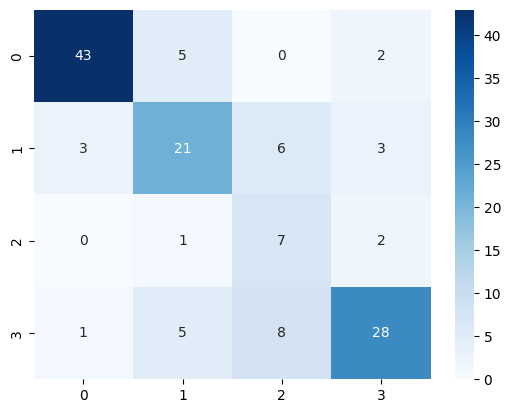

In [25]:
sns.heatmap(cf, annot = True, cmap = 'Blues')